In [1]:
# =======================
# CLUSTER ANALYSIS - BANK CHURNERS
# =======================

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# =======================
# STEP 1: Caricamento dati
# =======================
df_clean = pd.read_csv("./Dati_puliti/BankChurners_senza_predizione_NB.csv")
df_clean

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10122,Existing Customer,50,M,2,Graduate,Single,$40K - $60K,Blue,40,3,2,3,4003.0,1851,2152.0,0.703,15476,117,0.857,0.462
10123,Attrited Customer,41,M,2,Unknown,Divorced,$40K - $60K,Blue,25,4,2,3,4277.0,2186,2091.0,0.804,8764,69,0.683,0.511
10124,Attrited Customer,44,F,1,High School,Married,Less than $40K,Blue,36,5,3,4,5409.0,0,5409.0,0.819,10291,60,0.818,0.000
10125,Attrited Customer,30,M,2,Graduate,Unknown,$40K - $60K,Blue,36,4,3,3,5281.0,0,5281.0,0.535,8395,62,0.722,0.000


In [2]:
print("=" * 60)
print("DATASET CARICATO")
print("=" * 60)
print(f"Shape dataset pulito: {df_clean.shape}")

print(f"\nColonne: {list(df_clean.columns)}")

# =======================
# STEP 2: Definizione blocchi di feature
# =======================
blocks = {
    "Demografia": [
        "Customer_Age", "Gender", "Dependent_count",
        "Education_Level", "Marital_Status", "Income_Category"
    ],
    "Comportamento": [
        "Months_on_book", "Months_Inactive_12_mon",
        "Contacts_Count_12_mon", "Total_Relationship_Count"
    ],
    "Utilizzo": [
        "Credit_Limit", "Total_Revolving_Bal",
        "Avg_Open_To_Buy", "Avg_Utilization_Ratio"
    ],
    "Transazioni": [
        "Total_Trans_Amt", "Total_Trans_Ct",
        "Total_Amt_Chng_Q4_Q1", "Total_Ct_Chng_Q4_Q1"
    ]
}

DATASET CARICATO
Shape dataset pulito: (10127, 20)

Colonne: ['Attrition_Flag', 'Customer_Age', 'Gender', 'Dependent_count', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio']


In [3]:
# =======================
# STEP 3: Funzioni di utilità
# =======================
def build_preprocessor(features, df):
    """Crea un ColumnTransformer per numeriche (scaling) e categoriche (one-hot)."""
    numeric = df[features].select_dtypes(include=["int64", "float64"]).columns.tolist()
    categorical = df[features].select_dtypes(exclude=["int64", "float64"]).columns.tolist()
    
    transformers = []
    if numeric:
        transformers.append(("num", StandardScaler(), numeric))
    if categorical:
        transformers.append(("cat", OneHotEncoder(drop="first", sparse_output=False), categorical))
    
    preprocessor = ColumnTransformer(transformers)
    return preprocessor, numeric, categorical


def find_optimal_k(X, max_k=10):
    """Trova il k ottimale usando Elbow Method e Silhouette Score."""
    inertias = []
    silhouettes = []
    K_range = range(2, max_k + 1)
    
    for k in K_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X)
        inertias.append(kmeans.inertia_)
        silhouettes.append(silhouette_score(X, labels))
    
    # Trova il k ottimale (max silhouette)
    optimal_k = K_range[np.argmax(silhouettes)]
    
    return K_range, inertias, silhouettes, optimal_k


def evaluate_clusters(X, labels, target, block_name):
    """Valuta la qualità dei cluster."""
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    
    results = {
        "Block": block_name,
        "N_Clusters": n_clusters,
        "Silhouette": silhouette_score(X, labels) if n_clusters > 1 else -1,
        "Davies_Bouldin": davies_bouldin_score(X, labels) if n_clusters > 1 else -1,
        "Calinski_Harabasz": calinski_harabasz_score(X, labels) if n_clusters > 1 else -1
    }
    
    # Analisi churn per cluster
    df_temp = pd.DataFrame({"Cluster": labels, "Attrition": target})
    cluster_stats = df_temp.groupby("Cluster").agg({
        "Attrition": ["count", lambda x: (x == "Attrited Customer").sum(), 
                      lambda x: (x == "Attrited Customer").mean()]
    })
    cluster_stats.columns = ["Size", "Churned", "Churn_Rate"]
    
    return results, cluster_stats


def plot_cluster_analysis(K_range, inertias, silhouettes, optimal_k, block_name):
    """Plotta Elbow e Silhouette per trovare k ottimale."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Elbow plot
    axes[0].plot(K_range, inertias, 'bo-')
    axes[0].set_xlabel('Numero di Cluster (k)')
    axes[0].set_ylabel('Inertia')
    axes[0].set_title(f'Elbow Method - {block_name}')
    axes[0].grid(True, alpha=0.3)
    
    # Silhouette plot
    axes[1].plot(K_range, silhouettes, 'ro-')
    axes[1].axvline(optimal_k, color='g', linestyle='--', label=f'Ottimale k={optimal_k}')
    axes[1].set_xlabel('Numero di Cluster (k)')
    axes[1].set_ylabel('Silhouette Score')
    axes[1].set_title(f'Silhouette Analysis - {block_name}')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


def characterize_clusters(df, features, labels, block_name, numeric_cols, categorical_cols):
    """Caratterizza i cluster trovando le caratteristiche distintive."""
    df_analysis = df[features].copy()
    df_analysis['Cluster'] = labels
    
    print(f"\n{'=' * 60}")
    print(f"CARATTERIZZAZIONE CLUSTER - {block_name}")
    print(f"{'=' * 60}\n")
    
    # Analisi per ogni cluster
    for cluster_id in sorted(df_analysis['Cluster'].unique()):
        if cluster_id == -1:  # Noise in DBSCAN
            continue
            
        cluster_data = df_analysis[df_analysis['Cluster'] == cluster_id]
        print(f"\n--- CLUSTER {cluster_id} (n={len(cluster_data)}) ---")
        
        # Statistiche numeriche
        if numeric_cols:
            print("\nCaratteristiche numeriche medie:")
            for col in numeric_cols:
                cluster_mean = cluster_data[col].mean()
                overall_mean = df_analysis[col].mean()
                diff_pct = ((cluster_mean - overall_mean) / overall_mean) * 100
                print(f"  {col}: {cluster_mean:.2f} (media generale: {overall_mean:.2f}, diff: {diff_pct:+.1f}%)")
        
        # Statistiche categoriche
        if categorical_cols:
            print("\nDistribuzione variabili categoriche:")
            for col in categorical_cols:
                mode_val = cluster_data[col].mode()[0]
                mode_pct = (cluster_data[col] == mode_val).sum() / len(cluster_data) * 100
                print(f"  {col}: {mode_val} ({mode_pct:.1f}%)")

In [6]:
# =======================
# FUNZIONE VISUALIZZAZIONE MIGLIORATA PER DBSCAN
# =======================
def visualize_clusters_2d_enhanced(X, labels, target, block_name, method='PCA', algorithm='KMeans'):
    """
    Visualizza i cluster in 2D usando PCA o t-SNE.
    Versione migliorata che gestisce il rumore di DBSCAN.
    """
    if method == 'PCA':
        reducer = PCA(n_components=2, random_state=42)
    else:
        reducer = TSNE(n_components=2, random_state=42, perplexity=30)
    
    X_2d = reducer.fit_transform(X)
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot 1: Cluster
    # Per DBSCAN, evidenzia il rumore (label -1)
    if algorithm == 'DBSCAN' and -1 in labels:
        noise_mask = labels == -1
        cluster_mask = labels != -1
        
        # Prima plotta i punti di rumore in grigio
        axes[0].scatter(X_2d[noise_mask, 0], X_2d[noise_mask, 1], 
                       c='lightgray', alpha=0.3, s=20, label='Noise', 
                       edgecolors='gray', linewidth=0.2)
        
        # Poi plotta i cluster
        scatter1 = axes[0].scatter(X_2d[cluster_mask, 0], X_2d[cluster_mask, 1], 
                                  c=labels[cluster_mask], cmap='viridis', 
                                  alpha=0.6, s=30, edgecolors='k', linewidth=0.3)
        axes[0].legend()
        plt.colorbar(scatter1, ax=axes[0], label='Cluster')
    else:
        scatter1 = axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap='viridis', 
                                  alpha=0.6, s=30, edgecolors='k', linewidth=0.3)
        plt.colorbar(scatter1, ax=axes[0], label='Cluster')
    
    axes[0].set_title(f'{method} - Cluster {algorithm} ({block_name})')
    axes[0].set_xlabel(f'{method}1')
    axes[0].set_ylabel(f'{method}2')
    axes[0].grid(True, alpha=0.2)
    
    # Plot 2: Churn
    churn_binary = (target == "Attrited Customer").astype(int)
    scatter2 = axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c=churn_binary, 
                              cmap='RdYlGn_r', alpha=0.6, s=30, 
                              edgecolors='k', linewidth=0.3)
    axes[1].set_title(f'{method} - Churn ({block_name})')
    axes[1].set_xlabel(f'{method}1')
    axes[1].set_ylabel(f'{method}2')
    cbar = plt.colorbar(scatter2, ax=axes[1], label='Churn', ticks=[0, 1])
    cbar.ax.set_yticklabels(['No Churn', 'Churn'])
    axes[1].grid(True, alpha=0.2)
    
    plt.tight_layout()
    plt.show()
    
    if method == 'PCA':
        print(f"\nVarianza spiegata da PCA: {reducer.explained_variance_ratio_.sum():.2%}")
        print(f"  - PC1: {reducer.explained_variance_ratio_[0]:.2%}")
        print(f"  - PC2: {reducer.explained_variance_ratio_[1]:.2%}")


# =======================
# FUNZIONE PER TROVARE EPS OTTIMALE
# =======================
def find_optimal_eps_dbscan(X, min_samples=5, eps_range=None, n_tests=20):
    """
    Trova l'eps ottimale per DBSCAN testando un range di valori.
    Restituisce quello con il miglior Silhouette Score.
    
    Parameters:
    - eps_range: tuple (min_eps, max_eps) o None per auto-detect
    - n_tests: numero di valori di eps da testare
    """
    from sklearn.neighbors import NearestNeighbors
    
    neighbors = NearestNeighbors(n_neighbors=min_samples)
    neighbors_fit = neighbors.fit(X)
    distances, indices = neighbors_fit.kneighbors(X)
    distances = np.sort(distances[:, -1], axis=0)
    
    # Plotta le distanze k-nearest neighbor
    plt.figure(figsize=(12, 5))
    plt.plot(distances)
    plt.ylabel(f'{min_samples}-NN Distance')
    plt.xlabel('Data Points sorted by distance')
    plt.title('K-distance Graph for DBSCAN eps selection')
    plt.grid(True, alpha=0.3)
    
    # Determina il range di eps da testare
    if eps_range is None:
        # Range automatico basato sui percentili
        min_eps = np.percentile(distances, 50)
        max_eps = np.percentile(distances, 99)
        # Assicurati che 1.0 sia nel range se è ragionevole
        if min_eps < 1.0 < max_eps:
            pass  # 1.0 è già nel range
        elif max_eps < 1.0:
            max_eps = 1.5  # Estendi il range per includere 1.0
        elif min_eps > 1.0:
            min_eps = 0.5  # Estendi il range per includere 1.0
    else:
        min_eps, max_eps = eps_range
    
    # Genera valori di eps da testare, ASSICURANDOCI che 1.0 sia incluso
    eps_values = np.linspace(min_eps, max_eps, n_tests)
    # Aggiungi esplicitamente 1.0 se non è già vicino a un valore testato
    if not any(abs(eps - 1.0) < 0.05 for eps in eps_values):
        eps_values = np.sort(np.append(eps_values, 1.0))
    
    print(f"\nRange eps da testare: [{min_eps:.3f}, {max_eps:.3f}]")
    print(f"Numero di test: {len(eps_values)}")
    if 1.0 in eps_values or any(abs(eps - 1.0) < 0.01 for eps in eps_values):
        print("✓ eps=1.0 è incluso nei test")
    
    # Aggiungi linee per alcuni valori chiave
    key_values = [min_eps, 1.0, max_eps]
    colors = ['red', 'green', 'blue']
    for val, color in zip(key_values, colors):
        if min_eps <= val <= max_eps:
            plt.axhline(y=val, color=color, linestyle='--', 
                       label=f'eps={val:.2f}', alpha=0.7)
    
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # Testa diversi eps e trova il migliore
    results = []
    print("\nTesting eps values...")
    for eps_val in eps_values:
        dbscan_test = DBSCAN(eps=eps_val, min_samples=min_samples)
        labels_test = dbscan_test.fit_predict(X)
        
        n_clusters = len(set(labels_test)) - (1 if -1 in labels_test else 0)
        n_noise = list(labels_test).count(-1)
        
        if n_clusters > 1:
            sil_score = silhouette_score(X, labels_test)
        else:
            sil_score = -1
        
        results.append({
            'eps': eps_val,
            'n_clusters': n_clusters,
            'n_noise': n_noise,
            'noise_pct': n_noise / len(labels_test) * 100,
            'silhouette': sil_score
        })
    
    df_results = pd.DataFrame(results)
    
    # Mostra i risultati ordinati per silhouette
    print("\nTop 10 configurazioni per Silhouette Score:")
    top_results = df_results[df_results['silhouette'] > -1].nlargest(10, 'silhouette')
    print(top_results.to_string(index=False))
    
    # Plotta il grafico Silhouette vs eps
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Silhouette vs eps
    valid_results = df_results[df_results['silhouette'] > -1]
    axes[0].plot(valid_results['eps'], valid_results['silhouette'], 'bo-', linewidth=2)
    if len(valid_results) > 0:
        best_idx = valid_results['silhouette'].idxmax()
        best_eps = valid_results.loc[best_idx, 'eps']
        best_sil = valid_results.loc[best_idx, 'silhouette']
        axes[0].axvline(best_eps, color='red', linestyle='--', 
                       label=f'Ottimale: eps={best_eps:.3f}')
        axes[0].scatter([best_eps], [best_sil], color='red', s=200, zorder=5, marker='*')
    axes[0].set_xlabel('eps')
    axes[0].set_ylabel('Silhouette Score')
    axes[0].set_title('Silhouette Score vs eps')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()
    
    # Plot 2: Numero cluster vs eps
    axes[1].plot(df_results['eps'], df_results['n_clusters'], 'go-', linewidth=2)
    axes[1].set_xlabel('eps')
    axes[1].set_ylabel('Numero di Cluster')
    axes[1].set_title('Numero Cluster vs eps')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Trova il migliore (massimo silhouette, escludendo -1)
    valid_results = df_results[df_results['silhouette'] > -1]
    if len(valid_results) > 0:
        best_idx = valid_results['silhouette'].idxmax()
        best_eps = df_results.loc[best_idx, 'eps']
        print(f"\n✓ Miglior eps: {best_eps:.4f}")
        print(f"  Silhouette: {df_results.loc[best_idx, 'silhouette']:.3f}")
        print(f"  Cluster: {int(df_results.loc[best_idx, 'n_clusters'])}")
        print(f"  Noise: {int(df_results.loc[best_idx, 'n_noise'])} ({df_results.loc[best_idx, 'noise_pct']:.1f}%)")
        return best_eps
    else:
        # Fallback
        default_eps = 1.0
        print(f"\n⚠️ Nessun eps valido trovato, uso default: {default_eps:.4f}")
        return default_eps


# =======================
# FUNZIONE CLUSTERING COMPLETA PER BLOCCO
# =======================
def analyze_block_complete(block_name, features, df, max_k=8, dbscan_min_samples=5):
    """
    Analisi completa di un blocco di feature con KMeans e DBSCAN,
    includendo tutte le visualizzazioni.
    """
    print(f"\n\n{'=' * 80}")
    print(f"ANALISI BLOCCO: {block_name}")
    print(f"{'=' * 80}")
    print(f"Feature: {features}")
    
    # Preprocessing
    preprocessor, numeric_cols, categorical_cols = build_preprocessor(features, df)
    X = preprocessor.fit_transform(df[features])
    print(f"\nShape dati trasformati: {X.shape}")
    
    # ==================
    # KMEANS
    # ==================
    print(f"\n{'─' * 80}")
    print(f"KMEANS CLUSTERING")
    print(f"{'─' * 80}")
    
    K_range, inertias, silhouettes, optimal_k = find_optimal_k(X, max_k=max_k)
    plot_cluster_analysis(K_range, inertias, silhouettes, optimal_k, block_name)
    
    kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
    labels_kmeans = kmeans.fit_predict(X)
    
    results_kmeans, cluster_stats_kmeans = evaluate_clusters(
        X, labels_kmeans, df["Attrition_Flag"], f"{block_name} (KMeans)"
    )
    
    print(f"\nMetriche KMeans (k={optimal_k}):")
    print(f"  Silhouette: {results_kmeans['Silhouette']:.3f}")
    print(f"  Davies-Bouldin: {results_kmeans['Davies_Bouldin']:.3f}")
    print(f"  Calinski-Harabasz: {results_kmeans['Calinski_Harabasz']:.1f}")
    print(f"\nStatistiche Cluster KMeans:")
    print(cluster_stats_kmeans)
    
    # Visualizzazioni KMeans
    print(f"\n--- Visualizzazioni KMeans ---")
    visualize_clusters_2d_enhanced(X, labels_kmeans, df["Attrition_Flag"], 
                                  block_name, method='PCA', algorithm='KMeans')
    visualize_clusters_2d_enhanced(X, labels_kmeans, df["Attrition_Flag"], 
                                  block_name, method='t-SNE', algorithm='KMeans')
    
    # Caratterizzazione
    characterize_clusters(df, features, labels_kmeans, f"{block_name} (KMeans)", 
                         numeric_cols, categorical_cols)
    
    # ==================
    # DBSCAN
    # ==================
    print(f"\n{'─' * 80}")
    print(f"DBSCAN CLUSTERING")
    print(f"{'─' * 80}")
    
    # Trova eps ottimale
    print(f"\nRicerca eps ottimale (min_samples={dbscan_min_samples})...")
    #optimal_eps = find_optimal_eps_dbscan(X, )
    # Esempio: testa eps da 0.5 a 2.0
    optimal_eps = find_optimal_eps_dbscan(X, min_samples=dbscan_min_samples, 
                                           eps_range=(0.5, 1.5), 
                                           n_tests=30)
    
    dbscan = DBSCAN(eps=optimal_eps, min_samples=dbscan_min_samples)
    labels_dbscan = dbscan.fit_predict(X)
    
    n_clusters_dbscan = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
    n_noise = list(labels_dbscan).count(-1)
    
    print(f"\nParametri finali DBSCAN:")
    print(f"  eps: {optimal_eps:.4f}")
    print(f"  min_samples: {dbscan_min_samples}")
    print(f"  Cluster trovati: {n_clusters_dbscan}")
    print(f"  Punti di rumore: {n_noise} ({n_noise/len(labels_dbscan)*100:.1f}%)")
    
    if n_clusters_dbscan > 1:
        results_dbscan, cluster_stats_dbscan = evaluate_clusters(
            X, labels_dbscan, df["Attrition_Flag"], f"{block_name} (DBSCAN)"
        )
        
        print(f"\nMetriche DBSCAN:")
        print(f"  Silhouette: {results_dbscan['Silhouette']:.3f}")
        print(f"  Davies-Bouldin: {results_dbscan['Davies_Bouldin']:.3f}")
        print(f"  Calinski-Harabasz: {results_dbscan['Calinski_Harabasz']:.1f}")
        print(f"\nStatistiche Cluster DBSCAN:")
        print(cluster_stats_dbscan)
        
        # Visualizzazioni DBSCAN
        print(f"\n--- Visualizzazioni DBSCAN ---")
        visualize_clusters_2d_enhanced(X, labels_dbscan, df["Attrition_Flag"], 
                                      block_name, method='PCA', algorithm='DBSCAN')
        visualize_clusters_2d_enhanced(X, labels_dbscan, df["Attrition_Flag"], 
                                      block_name, method='t-SNE', algorithm='DBSCAN')
        
        # Caratterizzazione (escludi rumore)
        labels_no_noise = labels_dbscan[labels_dbscan != -1]
        df_no_noise = df[labels_dbscan != -1]
        if len(df_no_noise) > 0:
            characterize_clusters(df_no_noise, features, labels_no_noise, 
                                f"{block_name} (DBSCAN)", numeric_cols, categorical_cols)
        
        return results_kmeans, results_dbscan, labels_kmeans, labels_dbscan
    else:
        print("\n⚠️ DBSCAN non ha trovato cluster significativi.")
        return results_kmeans, None, labels_kmeans, labels_dbscan



ANALISI BLOCCO: Demografia
Feature: ['Customer_Age', 'Gender', 'Dependent_count', 'Education_Level', 'Marital_Status', 'Income_Category']

Shape dati trasformati: (10127, 17)

────────────────────────────────────────────────────────────────────────────────
KMEANS CLUSTERING
────────────────────────────────────────────────────────────────────────────────


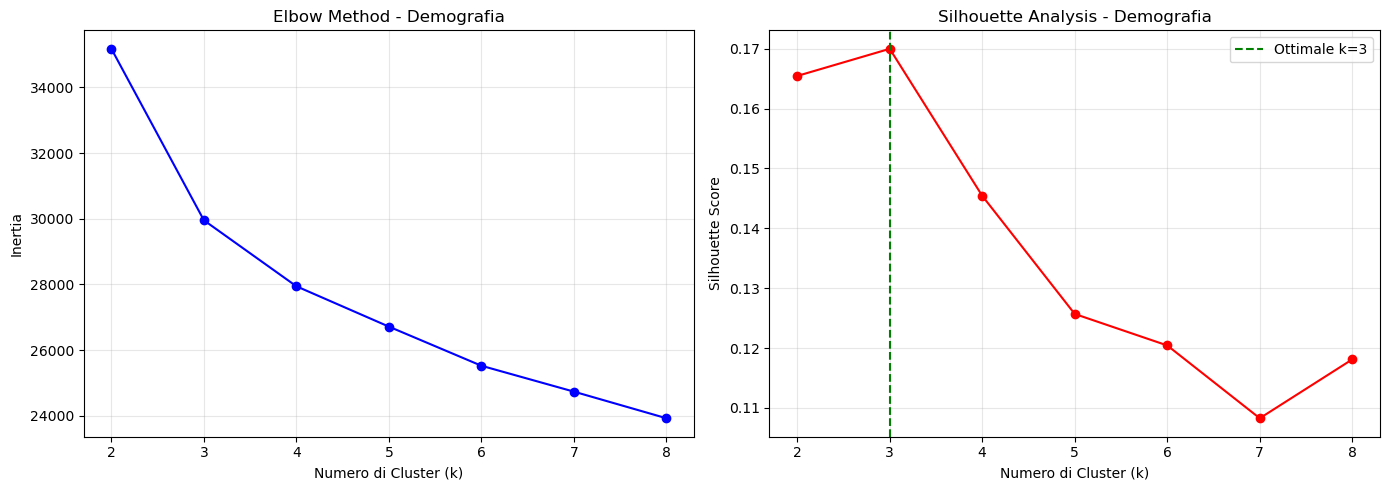


Metriche KMeans (k=3):
  Silhouette: 0.170
  Davies-Bouldin: 1.797
  Calinski-Harabasz: 2194.0

Statistiche Cluster KMeans:
         Size  Churned  Churn_Rate
Cluster                           
0        4277      731    0.170914
1        3261      520    0.159460
2        2589      376    0.145230

--- Visualizzazioni KMeans ---


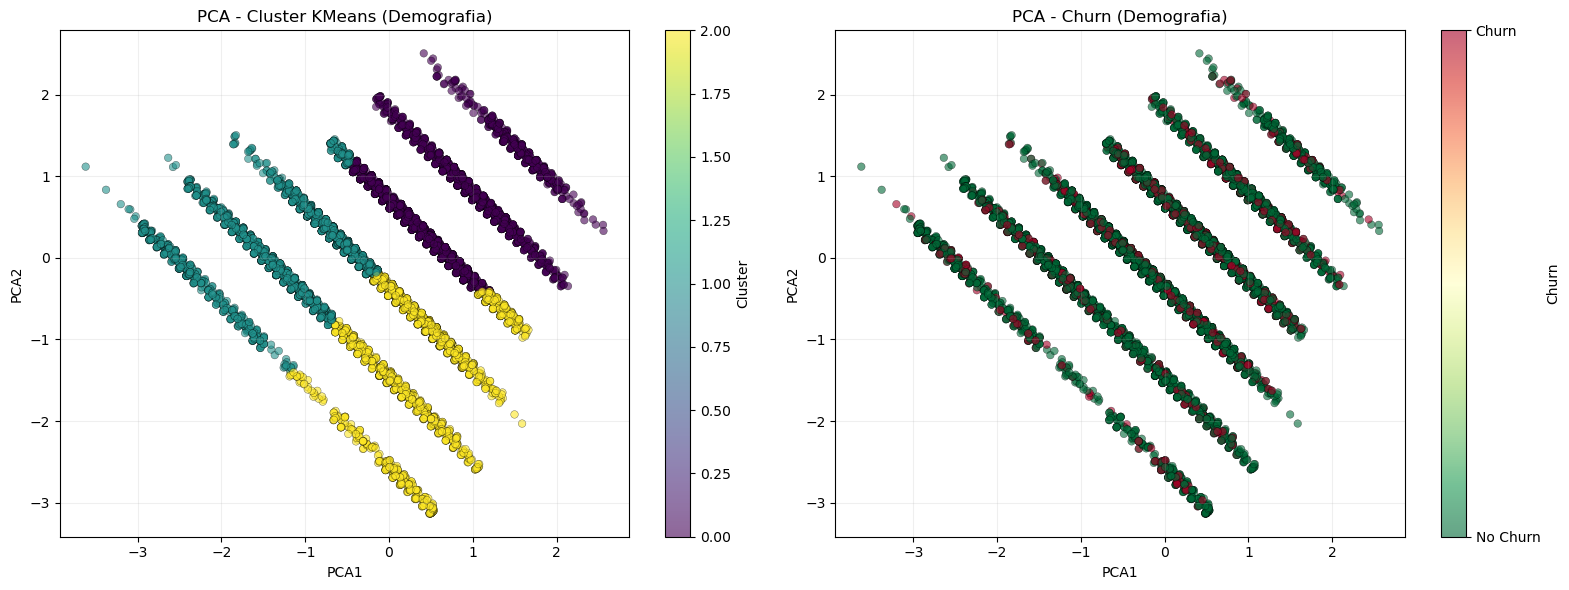


Varianza spiegata da PCA: 47.26%
  - PC1: 26.50%
  - PC2: 20.77%


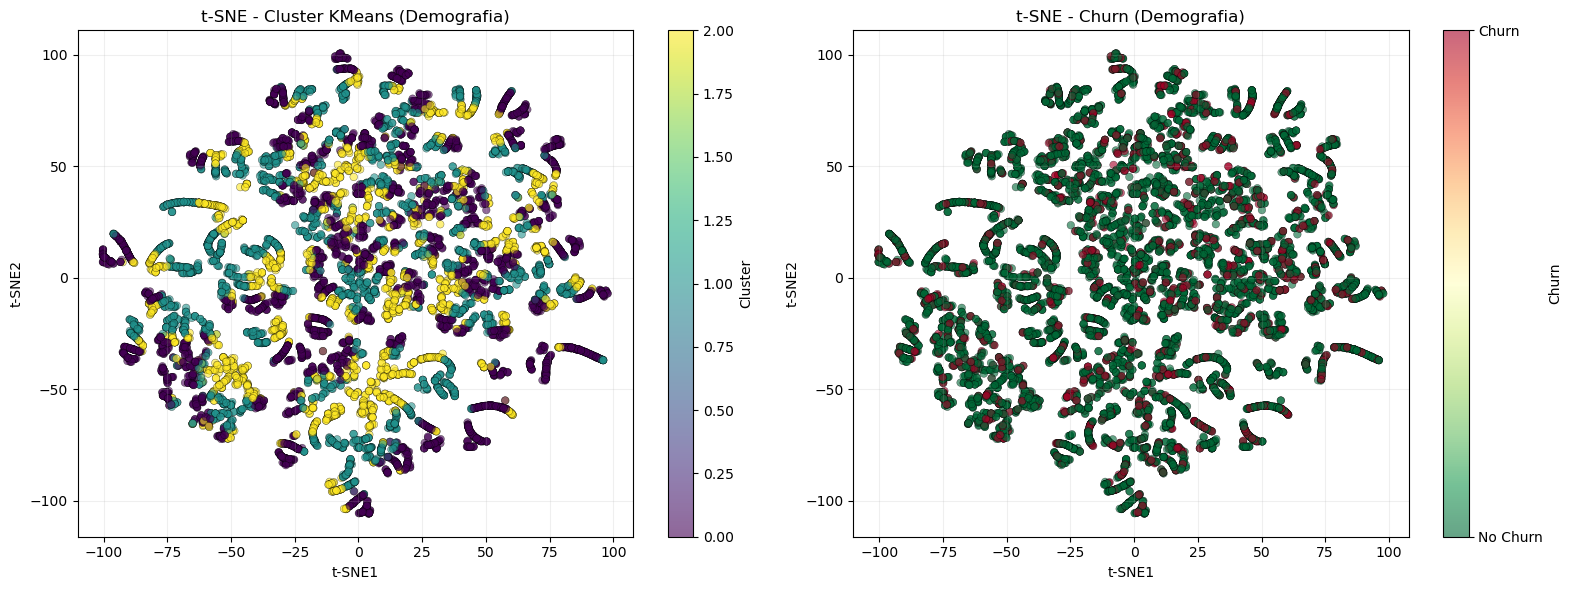


CARATTERIZZAZIONE CLUSTER - Demografia (KMeans)


--- CLUSTER 0 (n=4277) ---

Caratteristiche numeriche medie:
  Customer_Age: 45.73 (media generale: 46.33, diff: -1.3%)
  Dependent_count: 3.57 (media generale: 2.35, diff: +52.0%)

Distribuzione variabili categoriche:
  Gender: F (52.7%)
  Education_Level: Graduate (31.1%)
  Marital_Status: Married (46.3%)
  Income_Category: Less than $40K (33.6%)

--- CLUSTER 1 (n=3261) ---

Caratteristiche numeriche medie:
  Customer_Age: 54.19 (media generale: 46.33, diff: +17.0%)
  Dependent_count: 1.35 (media generale: 2.35, diff: -42.5%)

Distribuzione variabili categoriche:
  Gender: F (53.6%)
  Education_Level: Graduate (30.2%)
  Marital_Status: Married (50.3%)
  Income_Category: Less than $40K (35.4%)

--- CLUSTER 2 (n=2589) ---

Caratteristiche numeriche medie:
  Customer_Age: 37.40 (media generale: 46.33, diff: -19.3%)
  Dependent_count: 1.59 (media generale: 2.35, diff: -32.4%)

Distribuzione variabili categoriche:
  Gender: F (52.3%)
  Ed

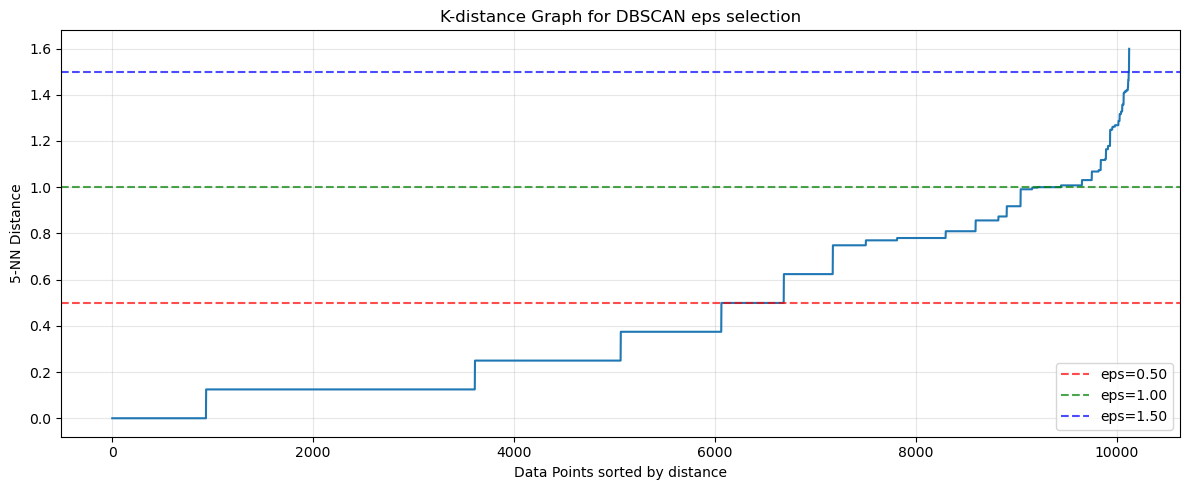


Testing eps values...

Top 10 configurazioni per Silhouette Score:
     eps  n_clusters  n_noise  noise_pct  silhouette
1.086207           2       68   0.671472    0.075001
1.051724           2       99   0.977585    0.074223
1.017241           2      135   1.333070    0.071703
0.637931         454     2306  22.770811    0.071630
0.672414         454     2306  22.770811    0.071630
0.706897         454     2306  22.770811    0.071630
0.741379         454     2306  22.770811    0.071630
0.500000         444     2713  26.789770    0.056458
0.534483         444     2713  26.789770    0.056458
0.568966         444     2713  26.789770    0.056458


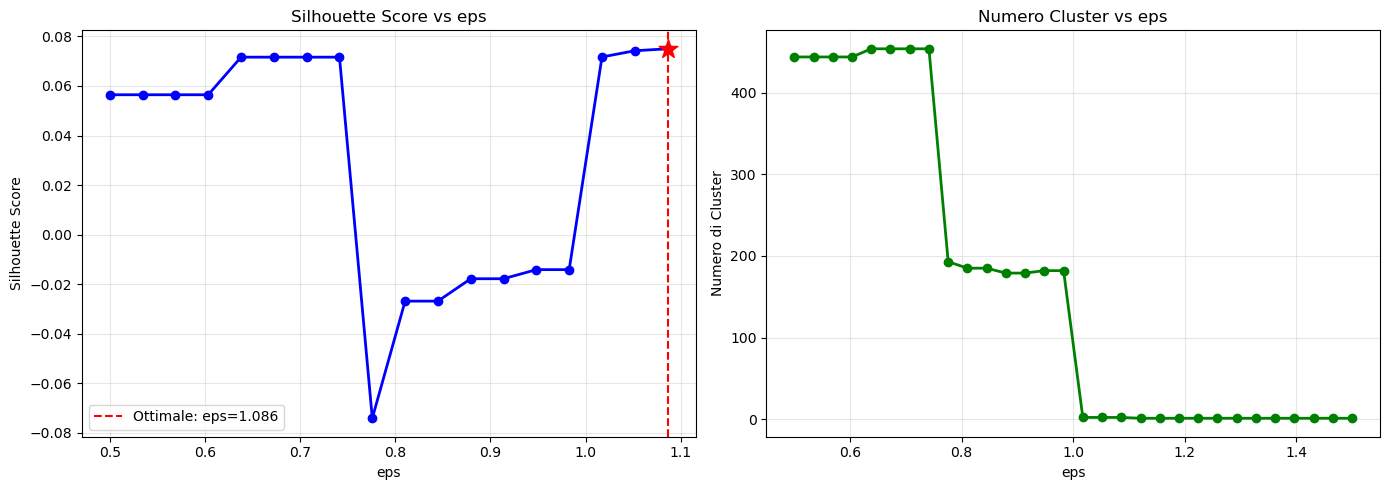


✓ Miglior eps: 1.0862
  Silhouette: 0.075
  Cluster: 2
  Noise: 68 (0.7%)

Parametri finali DBSCAN:
  eps: 1.0862
  min_samples: 5
  Cluster trovati: 2
  Punti di rumore: 68 (0.7%)

Metriche DBSCAN:
  Silhouette: 0.075
  Davies-Bouldin: 2.752
  Calinski-Harabasz: 17.3

Statistiche Cluster DBSCAN:
          Size  Churned  Churn_Rate
Cluster                            
-1          68        7    0.102941
 0       10054     1620    0.161130
 1           5        0    0.000000

--- Visualizzazioni DBSCAN ---


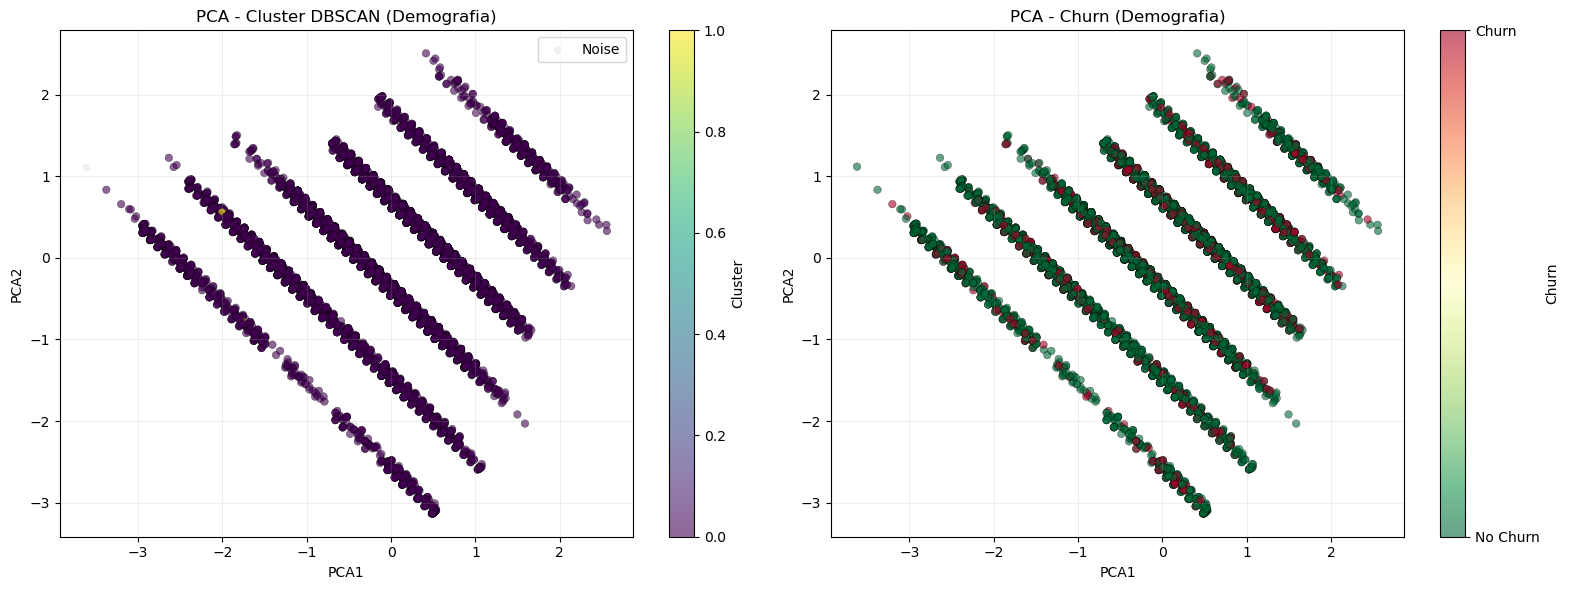


Varianza spiegata da PCA: 47.26%
  - PC1: 26.50%
  - PC2: 20.77%


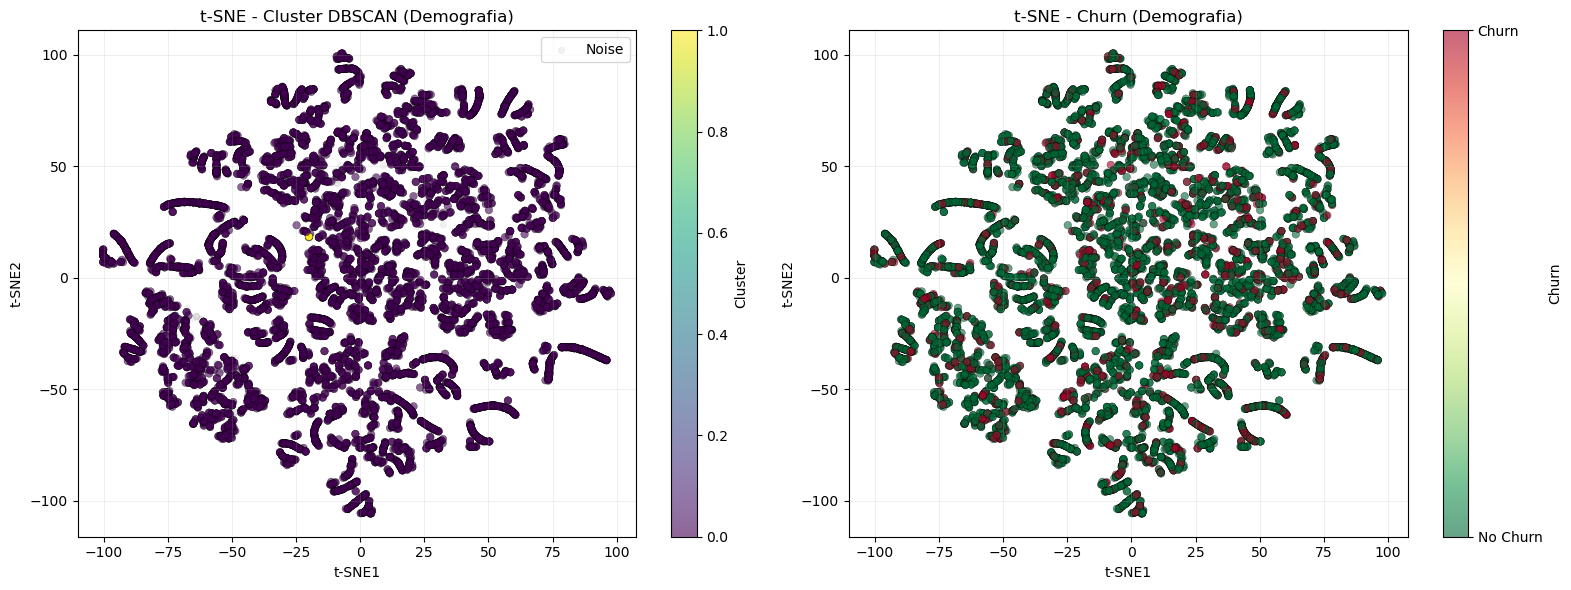


CARATTERIZZAZIONE CLUSTER - Demografia (DBSCAN)


--- CLUSTER 0 (n=10054) ---

Caratteristiche numeriche medie:
  Customer_Age: 46.34 (media generale: 46.34, diff: -0.0%)
  Dependent_count: 2.36 (media generale: 2.35, diff: +0.0%)

Distribuzione variabili categoriche:
  Gender: F (53.1%)
  Education_Level: Graduate (31.0%)
  Marital_Status: Married (46.5%)
  Income_Category: Less than $40K (35.3%)

--- CLUSTER 1 (n=5) ---

Caratteristiche numeriche medie:
  Customer_Age: 57.40 (media generale: 46.34, diff: +23.9%)
  Dependent_count: 0.80 (media generale: 2.35, diff: -66.0%)

Distribuzione variabili categoriche:
  Gender: F (100.0%)
  Education_Level: Graduate (100.0%)
  Marital_Status: Unknown (100.0%)
  Income_Category: $40K - $60K (100.0%)


ANALISI BLOCCO: Comportamento
Feature: ['Months_on_book', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Total_Relationship_Count']

Shape dati trasformati: (10127, 4)

───────────────────────────────────────────────────────────────────────

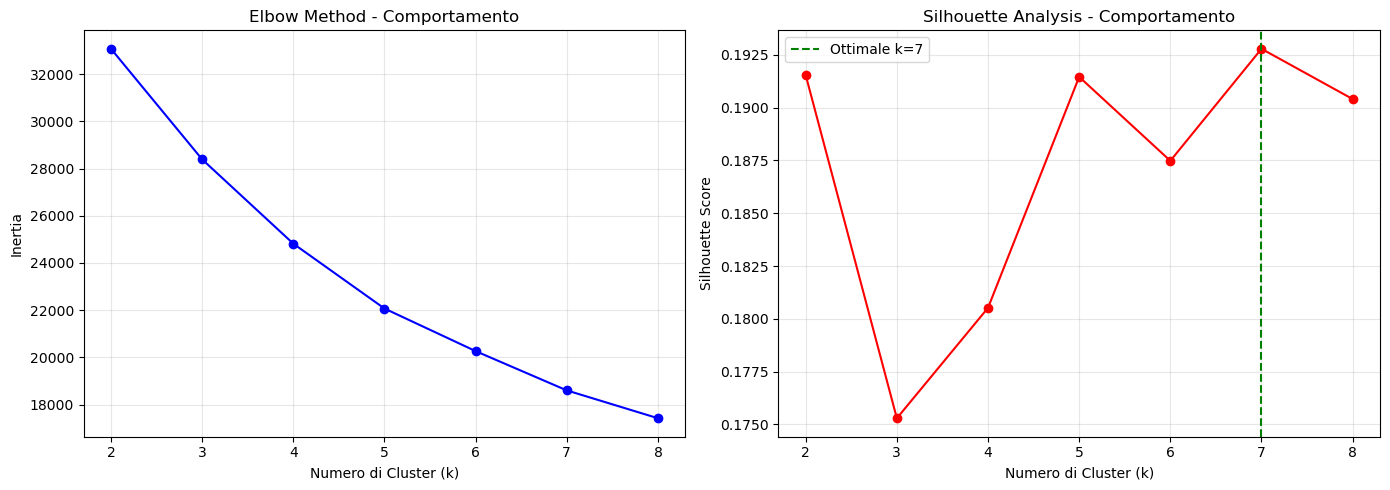


Metriche KMeans (k=7):
  Silhouette: 0.193
  Davies-Bouldin: 1.324
  Calinski-Harabasz: 1986.4

Statistiche Cluster KMeans:
         Size  Churned  Churn_Rate
Cluster                           
0        1185      159    0.134177
1        1887      244    0.129306
2        1507      484    0.321168
3         651      156    0.239631
4        1120      113    0.100893
5        1926      156    0.080997
6        1851      315    0.170178

--- Visualizzazioni KMeans ---


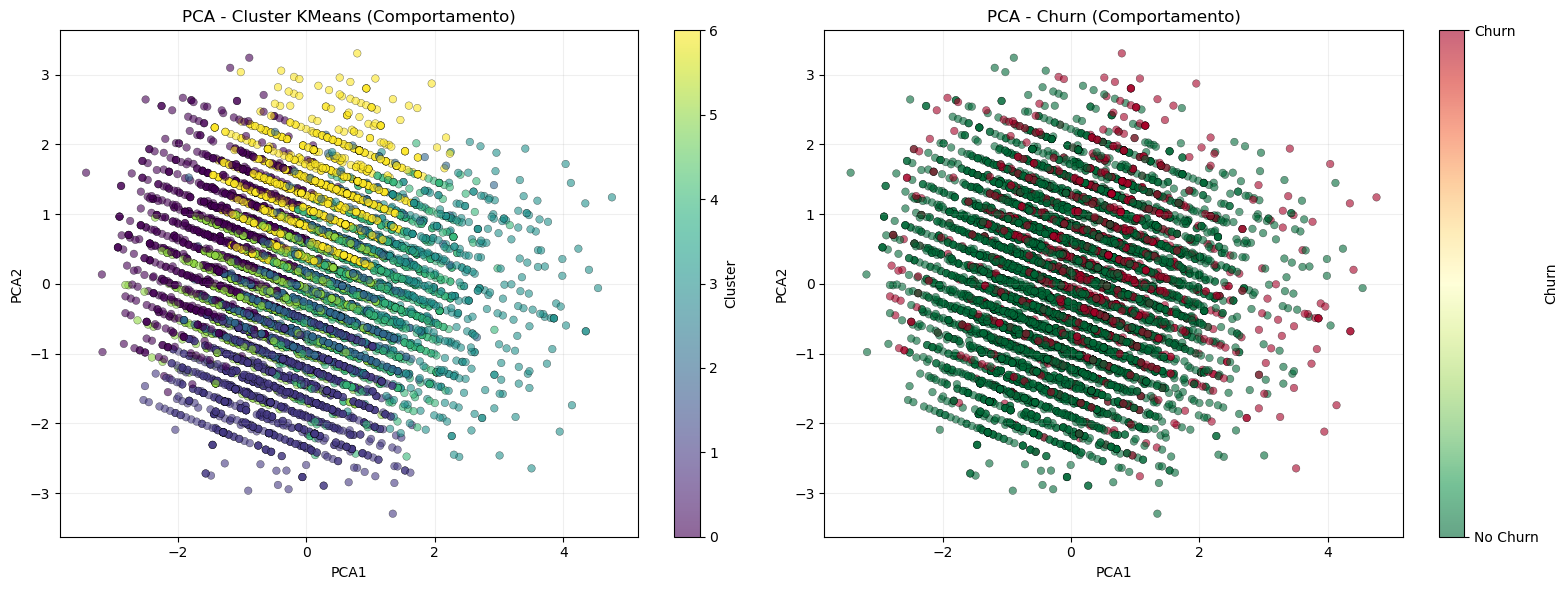


Varianza spiegata da PCA: 53.38%
  - PC1: 26.92%
  - PC2: 26.47%


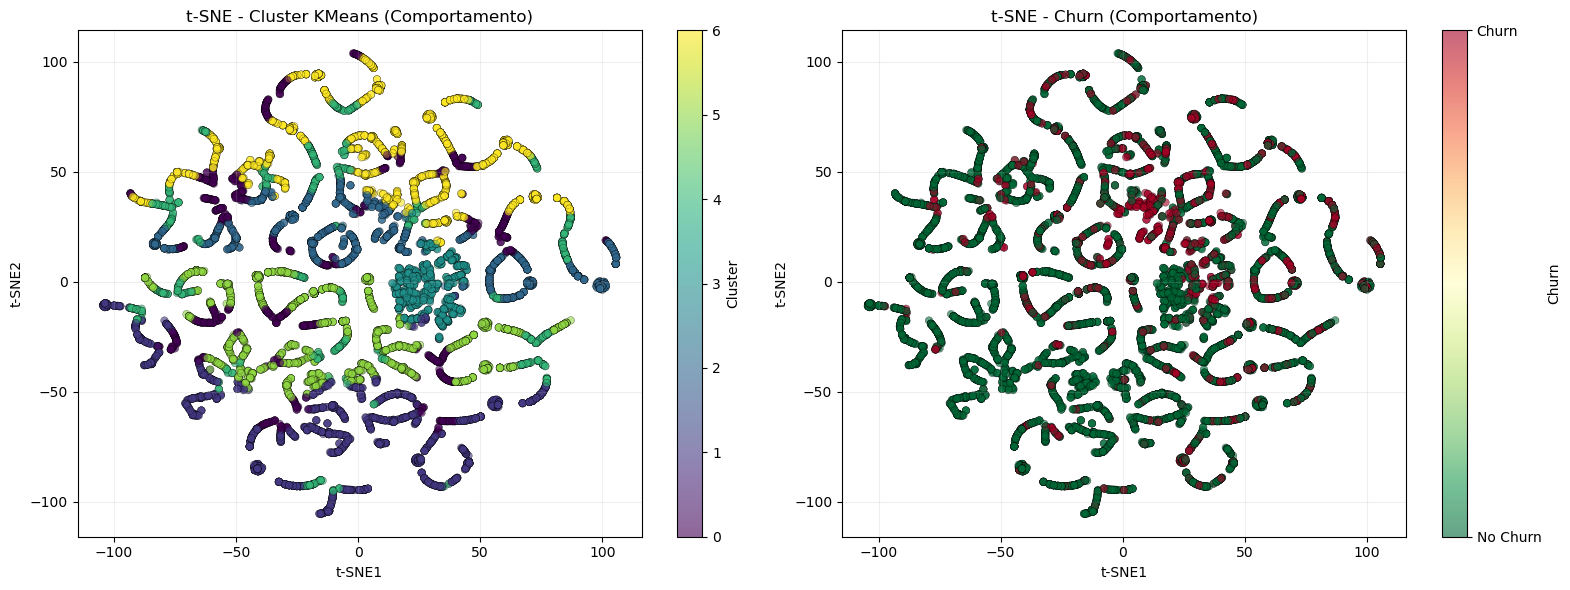


CARATTERIZZAZIONE CLUSTER - Comportamento (KMeans)


--- CLUSTER 0 (n=1185) ---

Caratteristiche numeriche medie:
  Months_on_book: 22.44 (media generale: 35.93, diff: -37.5%)
  Months_Inactive_12_mon: 2.03 (media generale: 2.34, diff: -13.3%)
  Contacts_Count_12_mon: 2.67 (media generale: 2.46, diff: +8.7%)
  Total_Relationship_Count: 4.01 (media generale: 3.81, diff: +5.1%)

--- CLUSTER 1 (n=1887) ---

Caratteristiche numeriche medie:
  Months_on_book: 36.16 (media generale: 35.93, diff: +0.6%)
  Months_Inactive_12_mon: 2.21 (media generale: 2.34, diff: -5.6%)
  Contacts_Count_12_mon: 1.49 (media generale: 2.46, diff: -39.3%)
  Total_Relationship_Count: 2.19 (media generale: 3.81, diff: -42.6%)

--- CLUSTER 2 (n=1507) ---

Caratteristiche numeriche medie:
  Months_on_book: 35.93 (media generale: 35.93, diff: +0.0%)
  Months_Inactive_12_mon: 2.27 (media generale: 2.34, diff: -3.0%)
  Contacts_Count_12_mon: 3.36 (media generale: 2.46, diff: +36.8%)
  Total_Relationship_Count: 2.25 (me

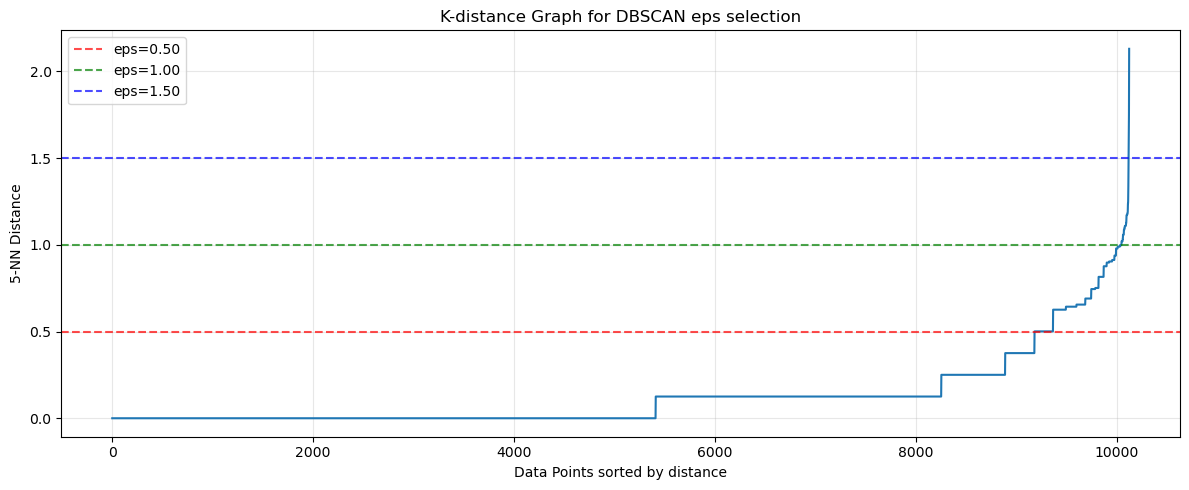


Testing eps values...

Top 10 configurazioni per Silhouette Score:
     eps  n_clusters  n_noise  noise_pct  silhouette
0.637931         132      456   4.502814    0.152871
0.534483         135      567   5.598894    0.141459
0.568966         135      567   5.598894    0.141459
0.603448         135      567   5.598894    0.141459
0.500000         136      727   7.178829    0.124091
0.879310          37      128   1.263948    0.096182
0.844828          39      146   1.441691    0.085804
0.913793           7       77   0.760344    0.082582
0.775862          39      172   1.698430    0.068167
0.810345          39      172   1.698430    0.068167


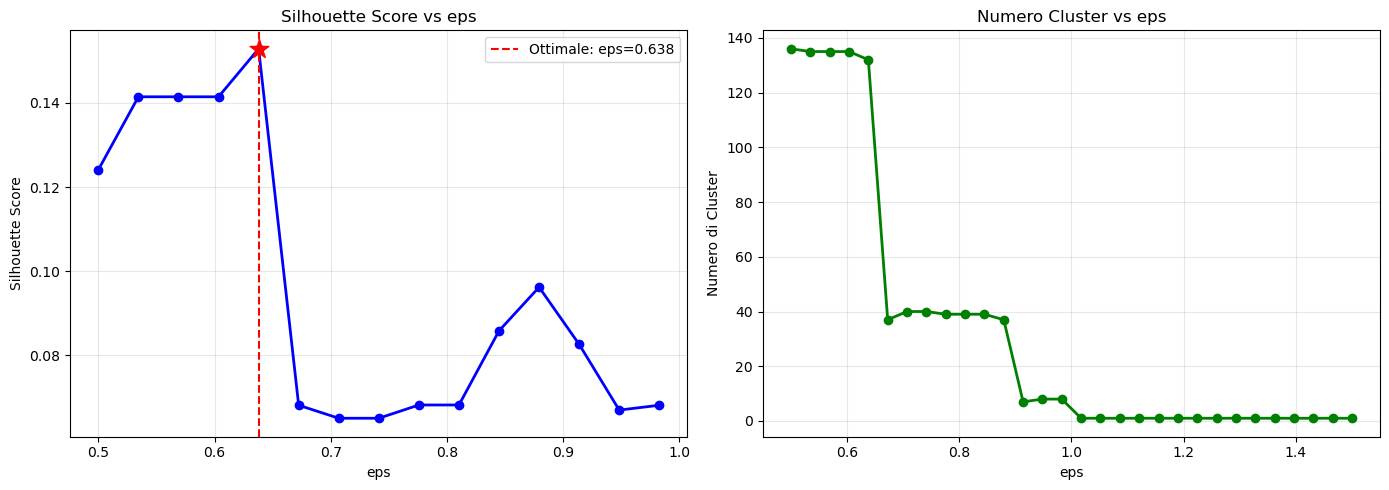


✓ Miglior eps: 0.6379
  Silhouette: 0.153
  Cluster: 132
  Noise: 456 (4.5%)

Parametri finali DBSCAN:
  eps: 0.6379
  min_samples: 5
  Cluster trovati: 132
  Punti di rumore: 456 (4.5%)

Metriche DBSCAN:
  Silhouette: 0.153
  Davies-Bouldin: 2.284
  Calinski-Harabasz: 152.0

Statistiche Cluster DBSCAN:
         Size  Churned  Churn_Rate
Cluster                           
-1        456      153    0.335526
 0        127        5    0.039370
 1        133        2    0.015038
 2         23        0    0.000000
 3         13        0    0.000000
...       ...      ...         ...
 127        5        4    0.800000
 128        6        1    0.166667
 129        7        7    1.000000
 130        6        6    1.000000
 131        6        0    0.000000

[133 rows x 3 columns]

--- Visualizzazioni DBSCAN ---


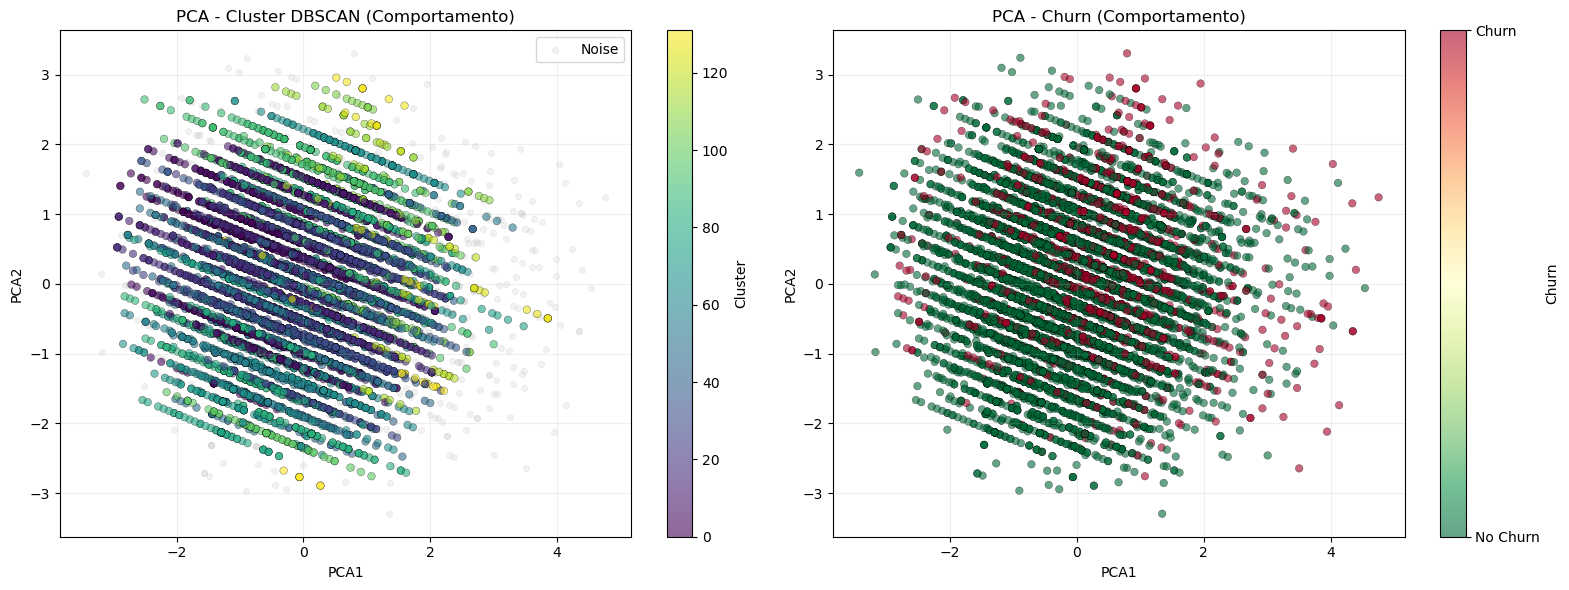


Varianza spiegata da PCA: 53.38%
  - PC1: 26.92%
  - PC2: 26.47%


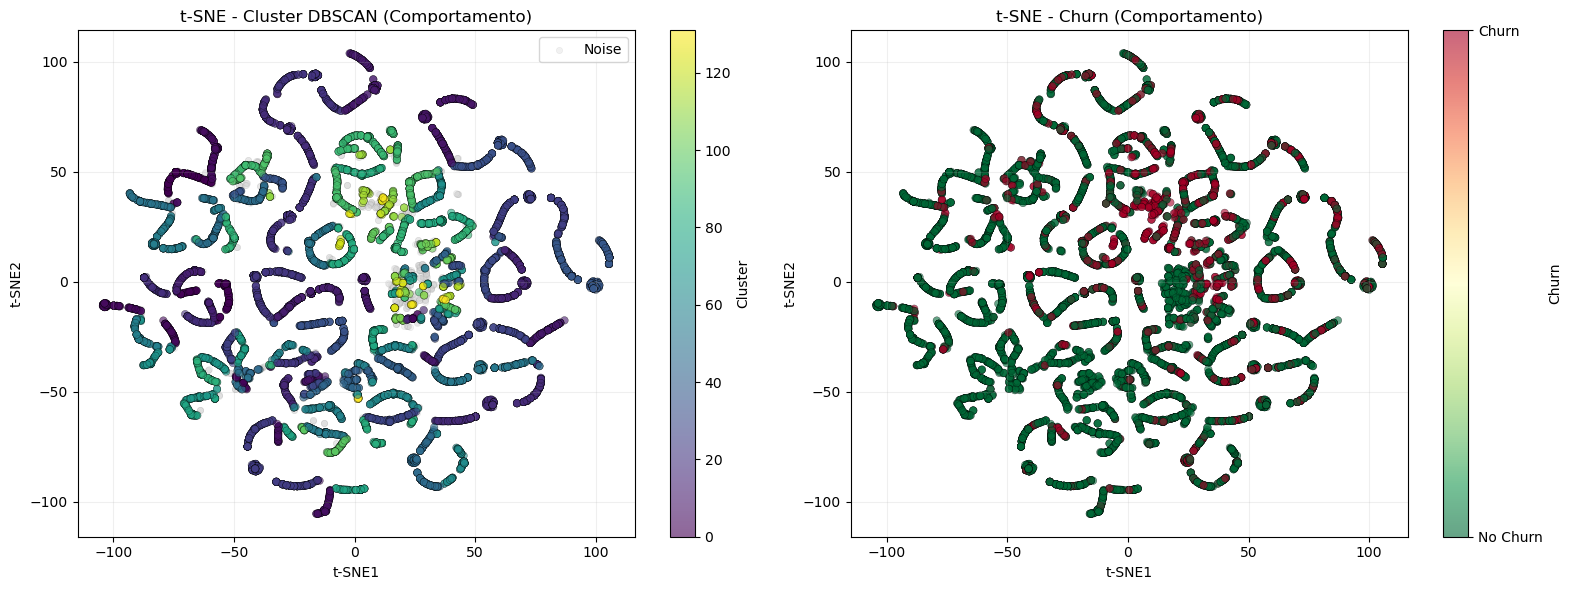


CARATTERIZZAZIONE CLUSTER - Comportamento (DBSCAN)


--- CLUSTER 0 (n=127) ---

Caratteristiche numeriche medie:
  Months_on_book: 34.87 (media generale: 35.85, diff: -2.8%)
  Months_Inactive_12_mon: 1.00 (media generale: 2.28, diff: -56.2%)
  Contacts_Count_12_mon: 3.00 (media generale: 2.43, diff: +23.3%)
  Total_Relationship_Count: 5.00 (media generale: 3.83, diff: +30.6%)

--- CLUSTER 1 (n=133) ---

Caratteristiche numeriche medie:
  Months_on_book: 35.90 (media generale: 35.85, diff: +0.1%)
  Months_Inactive_12_mon: 1.00 (media generale: 2.28, diff: -56.2%)
  Contacts_Count_12_mon: 2.00 (media generale: 2.43, diff: -17.8%)
  Total_Relationship_Count: 6.00 (media generale: 3.83, diff: +56.7%)

--- CLUSTER 2 (n=23) ---

Caratteristiche numeriche medie:
  Months_on_book: 37.43 (media generale: 35.85, diff: +4.4%)
  Months_Inactive_12_mon: 1.00 (media generale: 2.28, diff: -56.2%)
  Contacts_Count_12_mon: 0.00 (media generale: 2.43, diff: -100.0%)
  Total_Relationship_Count: 4.00 (me

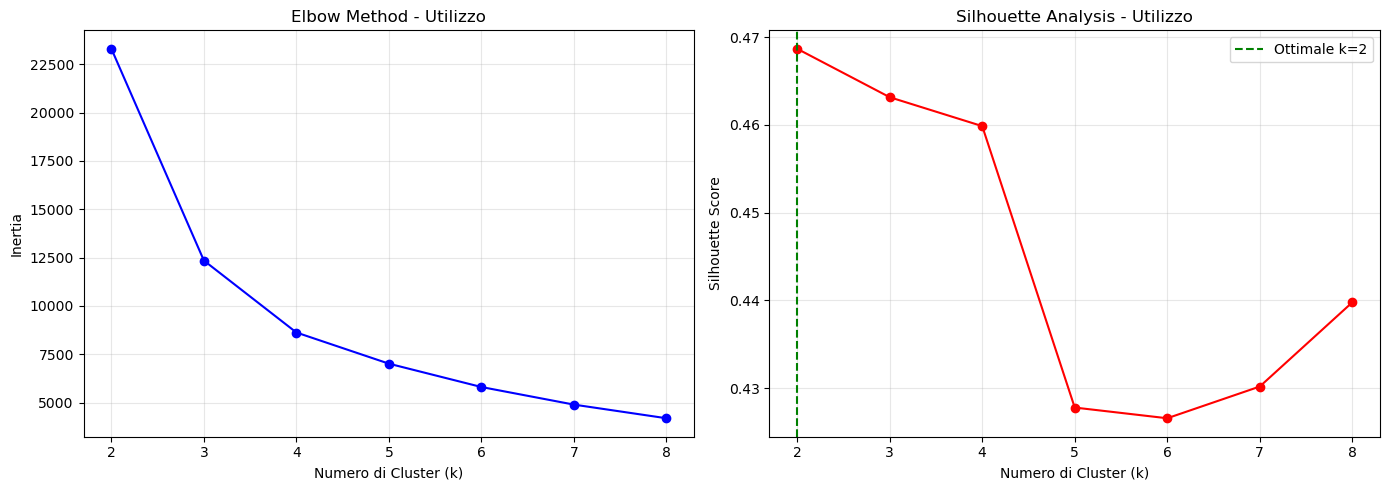


Metriche KMeans (k=2):
  Silhouette: 0.469
  Davies-Bouldin: 0.871
  Calinski-Harabasz: 7474.6

Statistiche Cluster KMeans:
         Size  Churned  Churn_Rate
Cluster                           
0        1994      296    0.148445
1        8133     1331    0.163654

--- Visualizzazioni KMeans ---


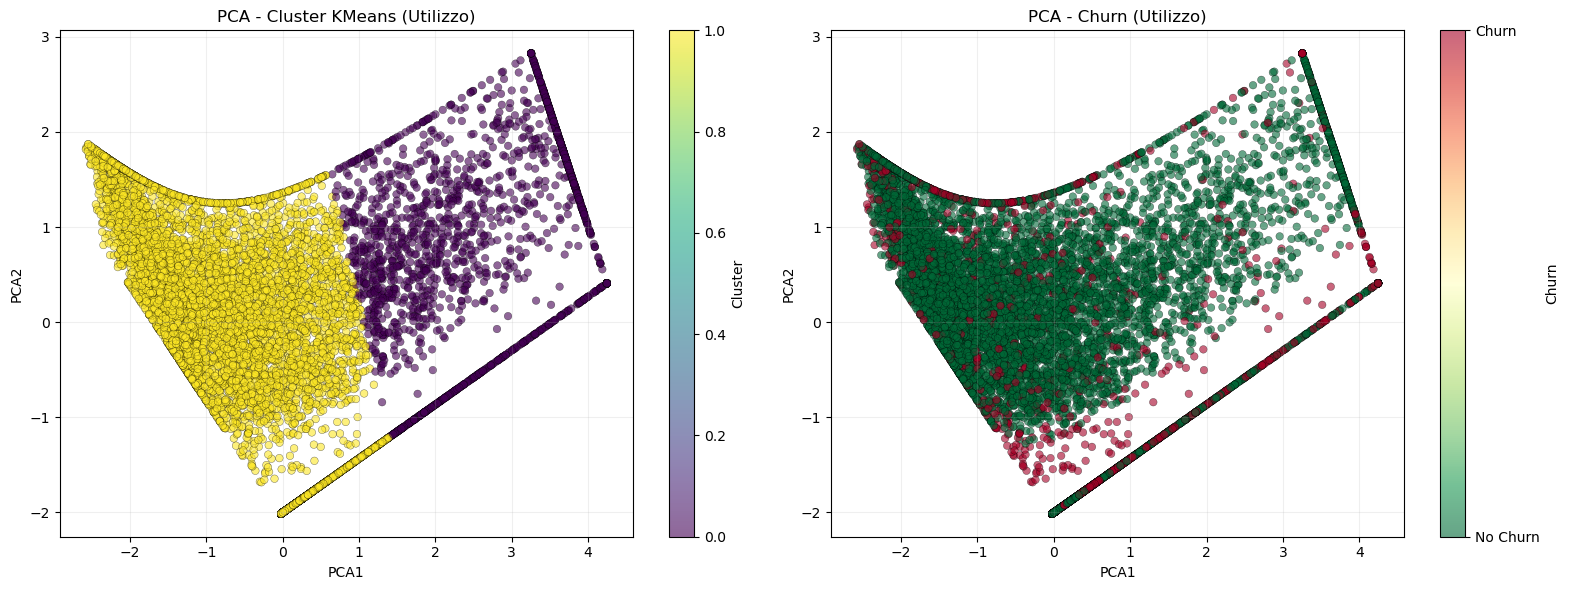


Varianza spiegata da PCA: 94.65%
  - PC1: 61.08%
  - PC2: 33.56%


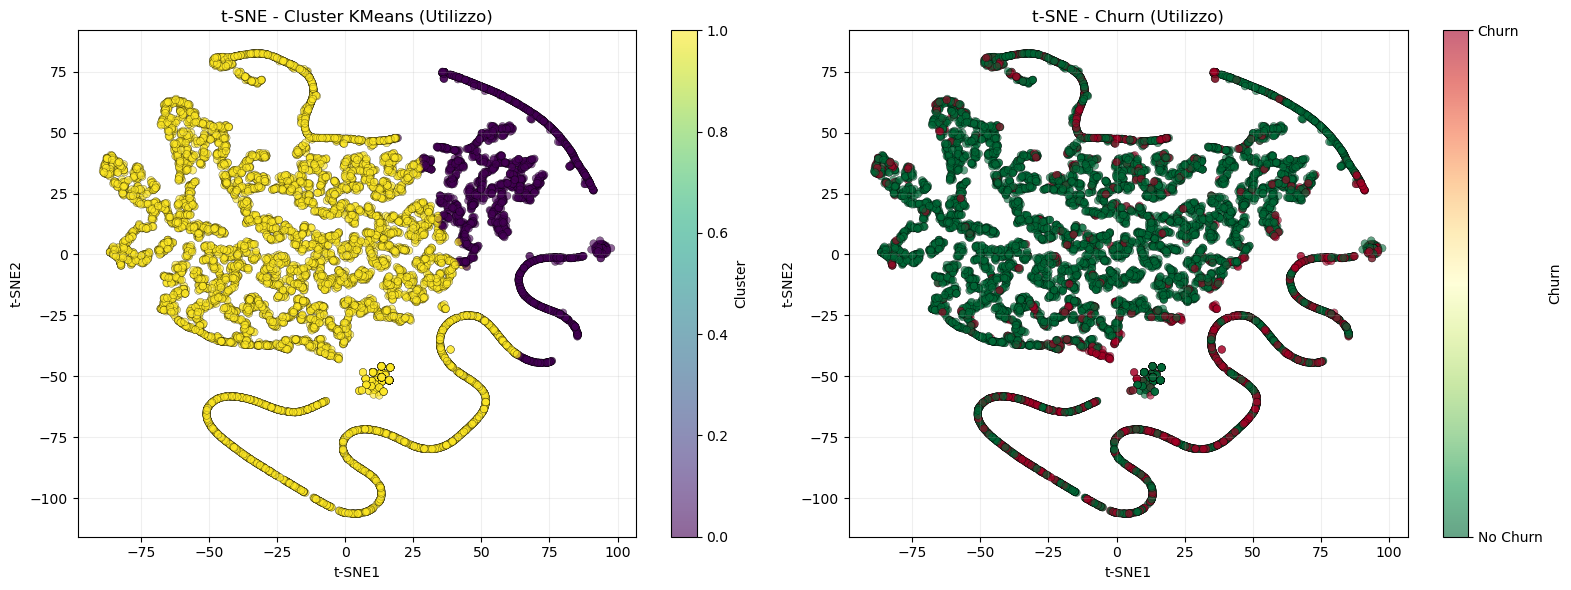


CARATTERIZZAZIONE CLUSTER - Utilizzo (KMeans)


--- CLUSTER 0 (n=1994) ---

Caratteristiche numeriche medie:
  Credit_Limit: 24672.67 (media generale: 8631.95, diff: +185.8%)
  Total_Revolving_Bal: 1117.22 (media generale: 1162.81, diff: -3.9%)
  Avg_Open_To_Buy: 23555.45 (media generale: 7469.14, diff: +215.4%)
  Avg_Utilization_Ratio: 0.05 (media generale: 0.27, diff: -82.6%)

--- CLUSTER 1 (n=8133) ---

Caratteristiche numeriche medie:
  Credit_Limit: 4699.19 (media generale: 8631.95, diff: -45.6%)
  Total_Revolving_Bal: 1173.99 (media generale: 1162.81, diff: +1.0%)
  Avg_Open_To_Buy: 3525.19 (media generale: 7469.14, diff: -52.8%)
  Avg_Utilization_Ratio: 0.33 (media generale: 0.27, diff: +20.3%)

────────────────────────────────────────────────────────────────────────────────
DBSCAN CLUSTERING
────────────────────────────────────────────────────────────────────────────────

Ricerca eps ottimale (min_samples=5)...

Range eps da testare: [0.500, 1.500]
Numero di test: 30


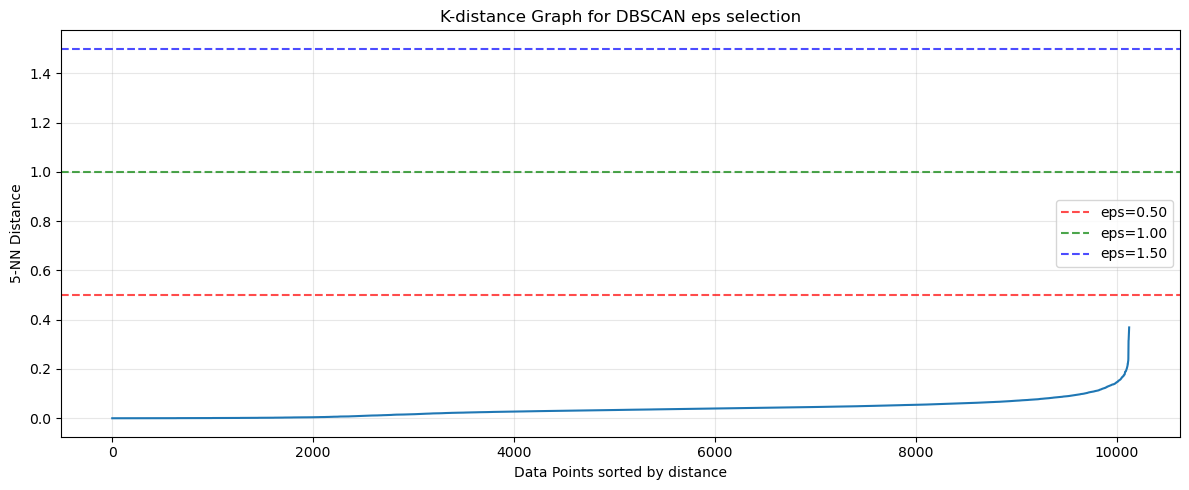


Testing eps values...

Top 10 configurazioni per Silhouette Score:
Empty DataFrame
Columns: [eps, n_clusters, n_noise, noise_pct, silhouette]
Index: []


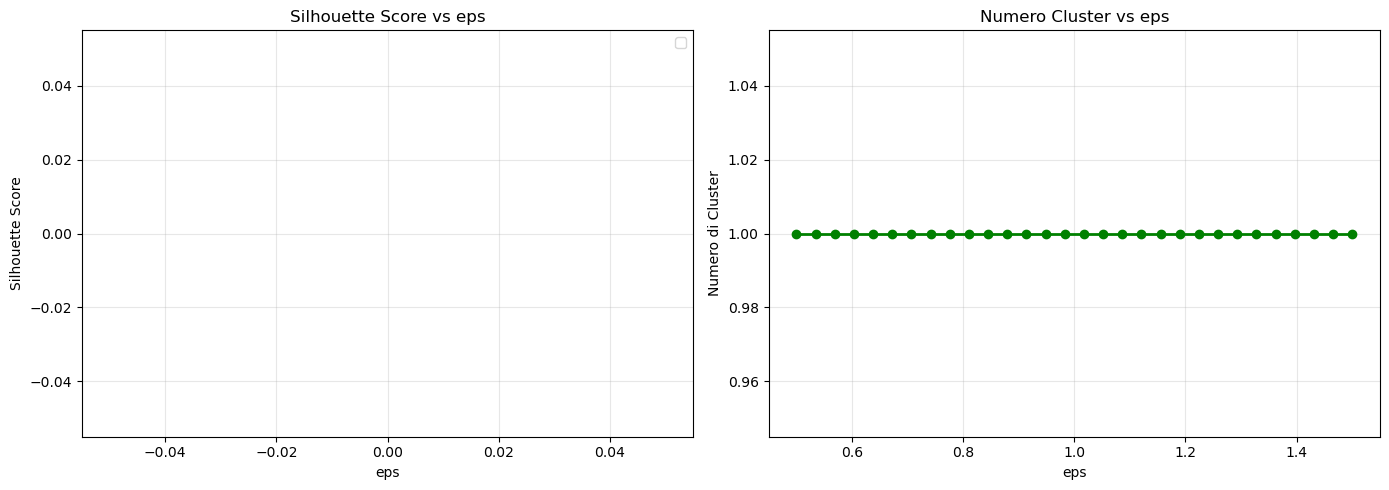


⚠️ Nessun eps valido trovato, uso default: 1.0000

Parametri finali DBSCAN:
  eps: 1.0000
  min_samples: 5
  Cluster trovati: 1
  Punti di rumore: 0 (0.0%)

⚠️ DBSCAN non ha trovato cluster significativi.


ANALISI BLOCCO: Transazioni
Feature: ['Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Amt_Chng_Q4_Q1', 'Total_Ct_Chng_Q4_Q1']

Shape dati trasformati: (10127, 4)

────────────────────────────────────────────────────────────────────────────────
KMEANS CLUSTERING
────────────────────────────────────────────────────────────────────────────────


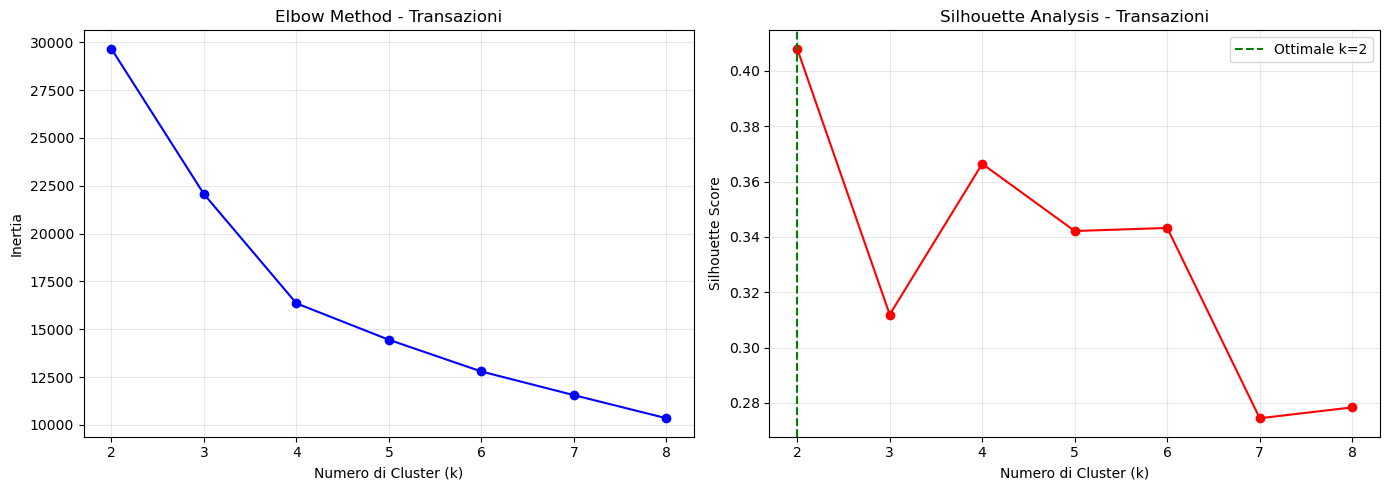


Metriche KMeans (k=2):
  Silhouette: 0.408
  Davies-Bouldin: 0.878
  Calinski-Harabasz: 3705.0

Statistiche Cluster KMeans:
         Size  Churned  Churn_Rate
Cluster                           
0        8916     1544    0.173172
1        1211       83    0.068538

--- Visualizzazioni KMeans ---


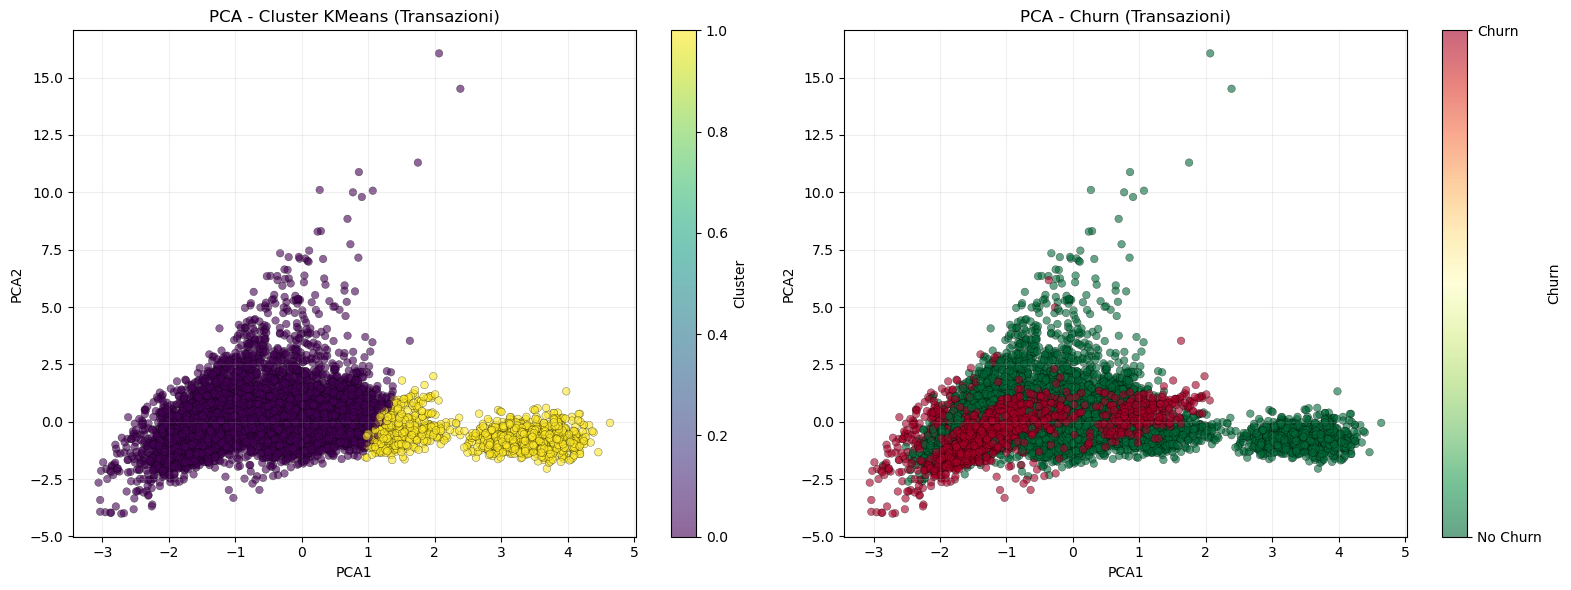


Varianza spiegata da PCA: 79.91%
  - PC1: 46.10%
  - PC2: 33.81%


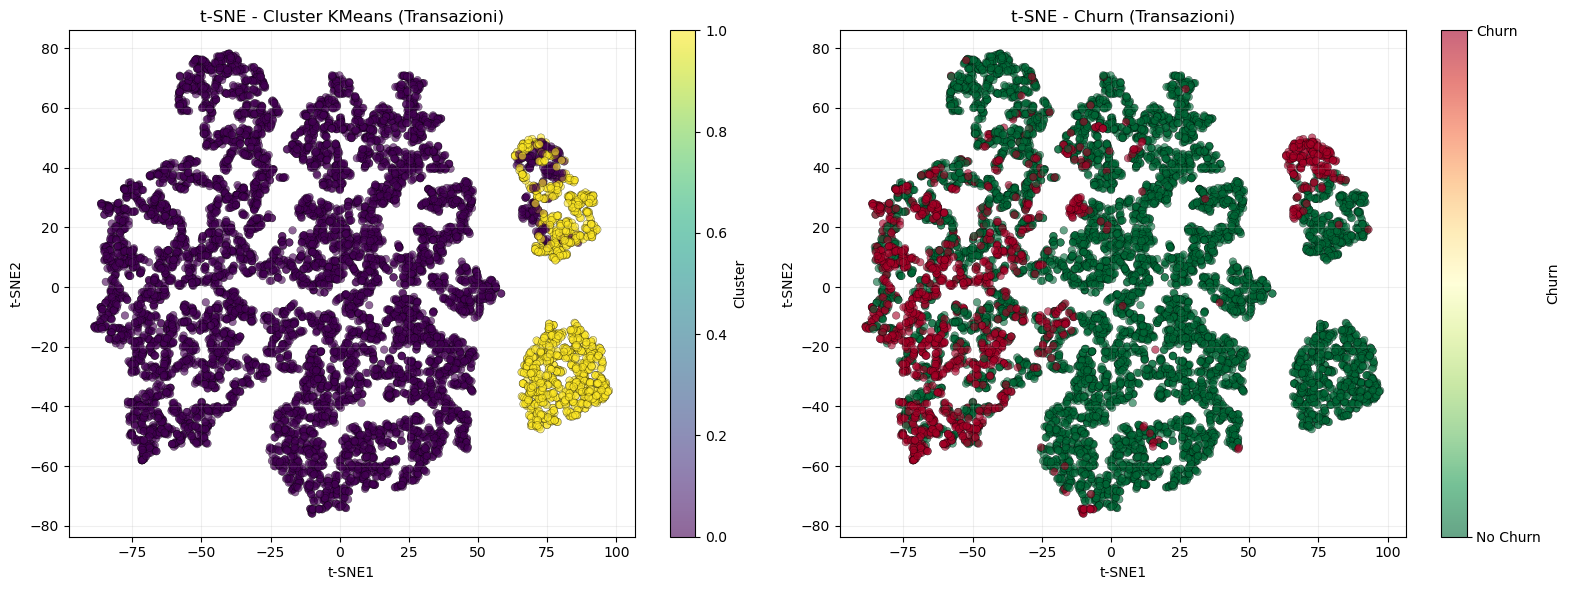


CARATTERIZZAZIONE CLUSTER - Transazioni (KMeans)


--- CLUSTER 0 (n=8916) ---

Caratteristiche numeriche medie:
  Total_Trans_Amt: 3342.13 (media generale: 4404.09, diff: -24.1%)
  Total_Trans_Ct: 59.74 (media generale: 64.86, diff: -7.9%)
  Total_Amt_Chng_Q4_Q1: 0.76 (media generale: 0.76, diff: -0.4%)
  Total_Ct_Chng_Q4_Q1: 0.71 (media generale: 0.71, diff: -0.2%)

--- CLUSTER 1 (n=1211) ---

Caratteristiche numeriche medie:
  Total_Trans_Amt: 12222.76 (media generale: 4404.09, diff: +177.5%)
  Total_Trans_Ct: 102.57 (media generale: 64.86, diff: +58.1%)
  Total_Amt_Chng_Q4_Q1: 0.78 (media generale: 0.76, diff: +2.6%)
  Total_Ct_Chng_Q4_Q1: 0.72 (media generale: 0.71, diff: +1.7%)

────────────────────────────────────────────────────────────────────────────────
DBSCAN CLUSTERING
────────────────────────────────────────────────────────────────────────────────

Ricerca eps ottimale (min_samples=5)...

Range eps da testare: [0.500, 1.500]
Numero di test: 30


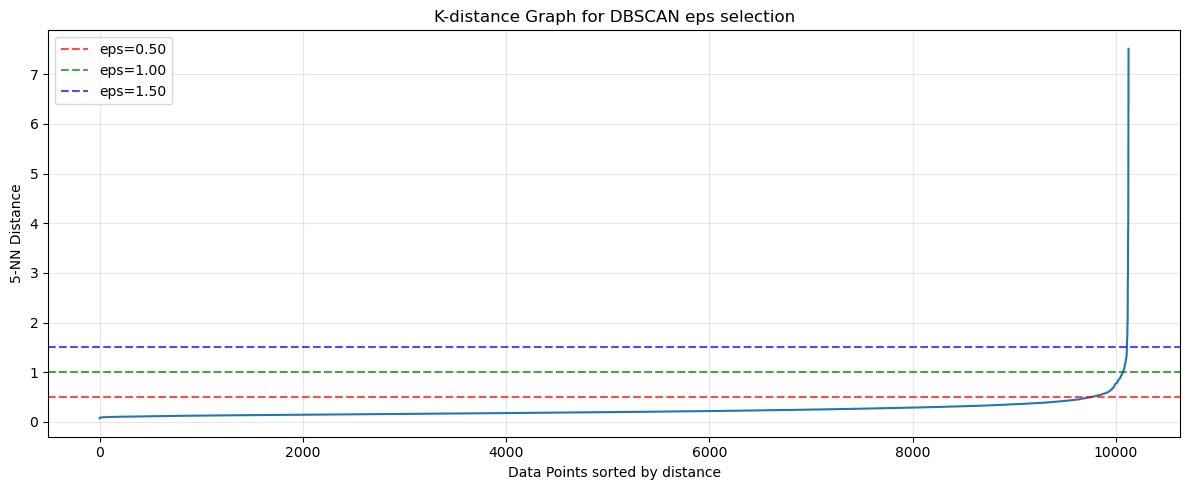


Testing eps values...

Top 10 configurazioni per Silhouette Score:
     eps  n_clusters  n_noise  noise_pct  silhouette
1.051724           2       21   0.207366    0.701148
1.189655           2       15   0.148119    0.699669
1.086207           3       18   0.177743    0.685446
1.120690           3       16   0.157993    0.685304
1.155172           3       15   0.148119    0.685258
0.948276           2       32   0.315987    0.620051
0.913793           2       37   0.365360    0.619961
0.879310           2       43   0.424607    0.614581
0.982759           2       28   0.276489    0.613877
0.741379           3       90   0.888713    0.482734


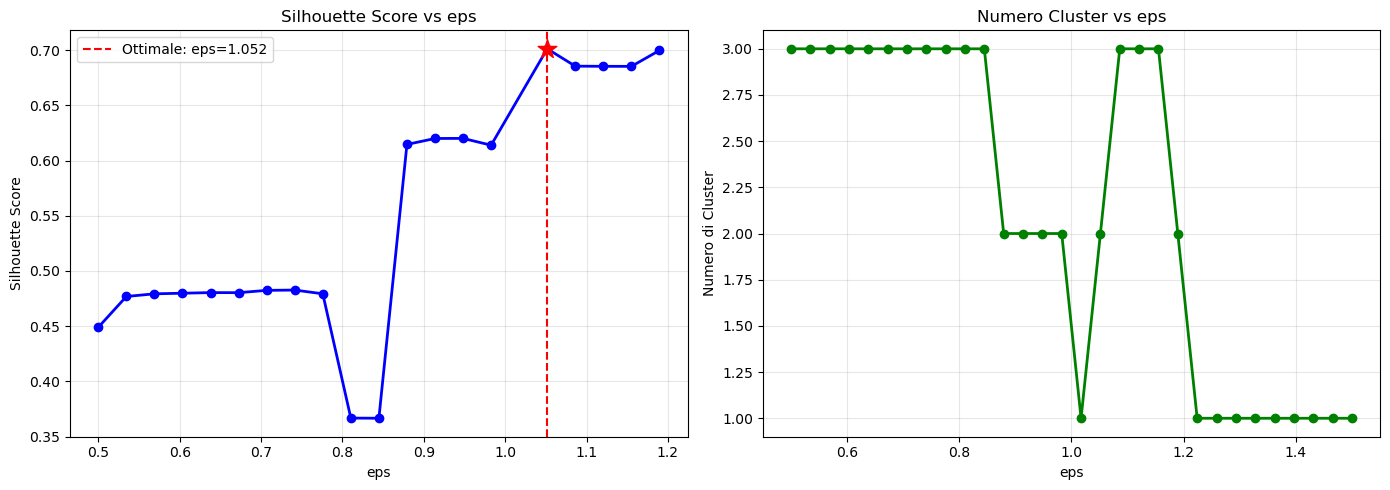


✓ Miglior eps: 1.0517
  Silhouette: 0.701
  Cluster: 2
  Noise: 21 (0.2%)

Parametri finali DBSCAN:
  eps: 1.0517
  min_samples: 5
  Cluster trovati: 2
  Punti di rumore: 21 (0.2%)

Metriche DBSCAN:
  Silhouette: 0.701
  Davies-Bouldin: 0.877
  Calinski-Harabasz: 241.0

Statistiche Cluster DBSCAN:
          Size  Churned  Churn_Rate
Cluster                            
-1          21        2    0.095238
 0       10102     1624    0.160760
 1           4        1    0.250000

--- Visualizzazioni DBSCAN ---


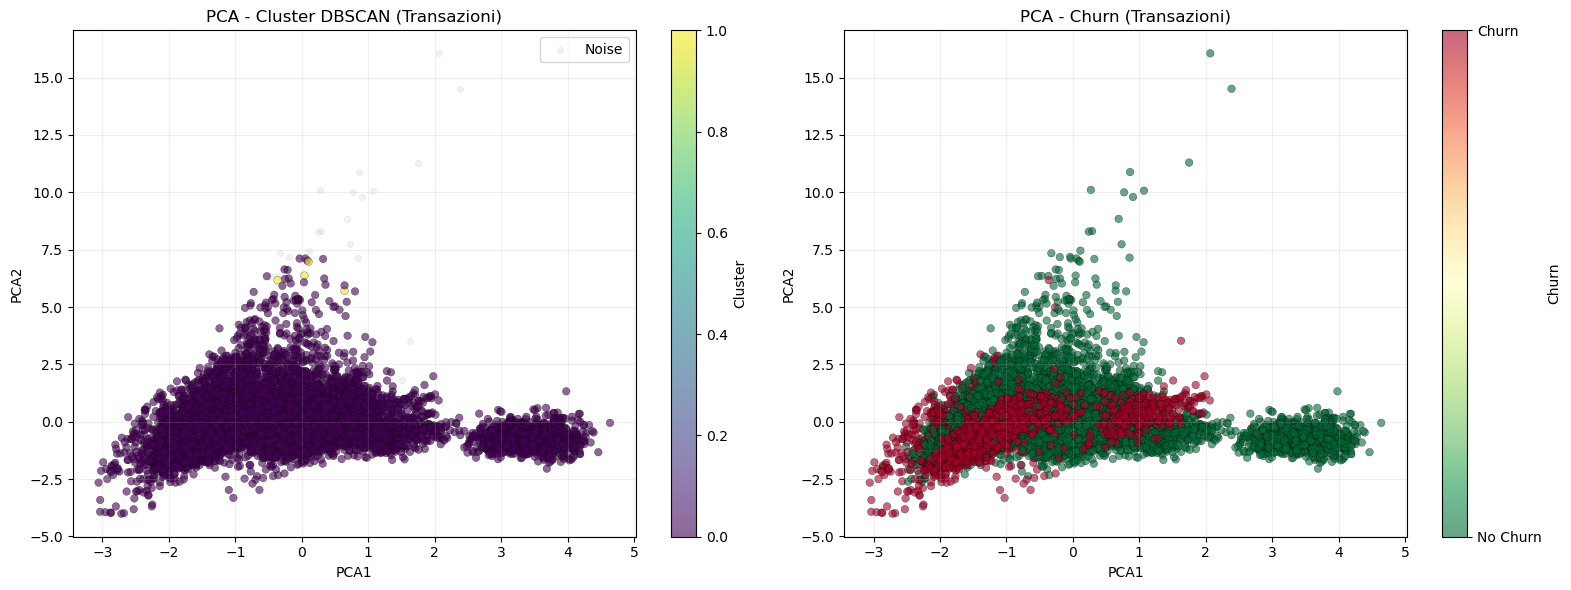


Varianza spiegata da PCA: 79.91%
  - PC1: 46.10%
  - PC2: 33.81%


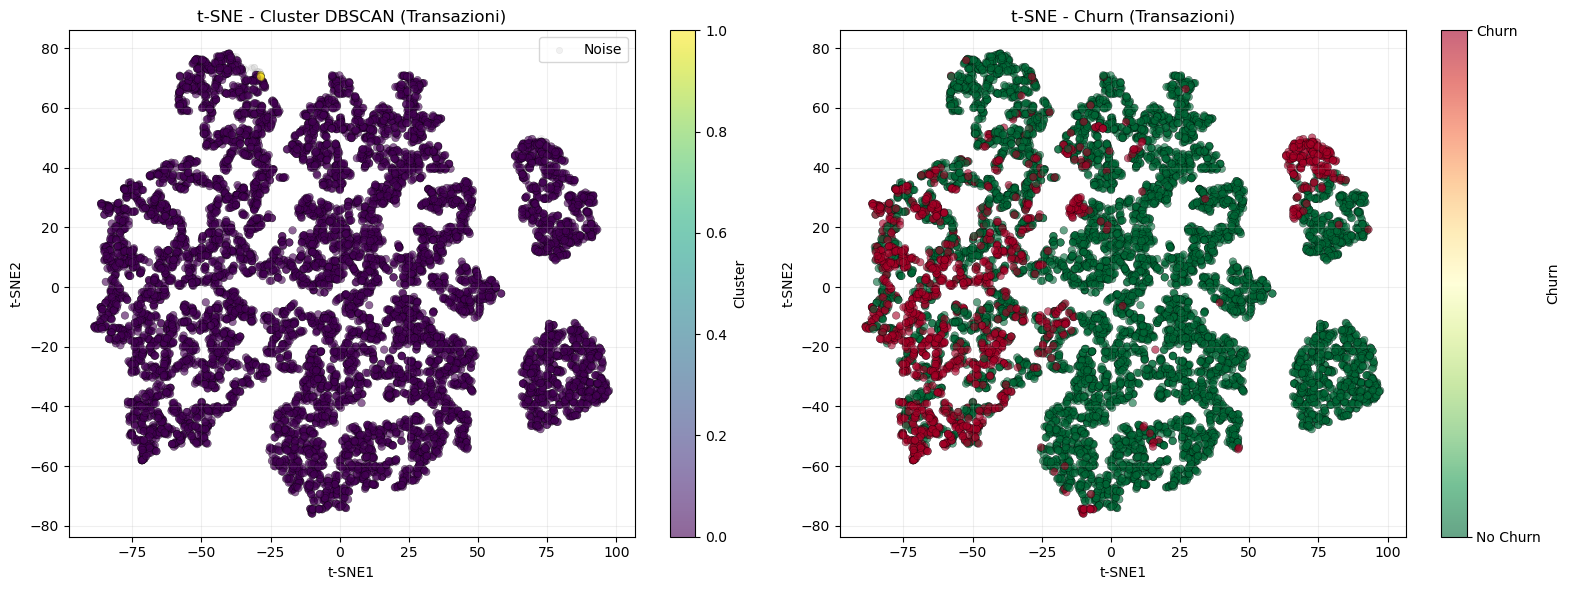


CARATTERIZZAZIONE CLUSTER - Transazioni (DBSCAN)


--- CLUSTER 0 (n=10102) ---

Caratteristiche numeriche medie:
  Total_Trans_Amt: 4409.54 (media generale: 4408.41, diff: +0.0%)
  Total_Trans_Ct: 64.95 (media generale: 64.93, diff: +0.0%)
  Total_Amt_Chng_Q4_Q1: 0.76 (media generale: 0.76, diff: -0.0%)
  Total_Ct_Chng_Q4_Q1: 0.71 (media generale: 0.71, diff: -0.1%)

--- CLUSTER 1 (n=4) ---

Caratteristiche numeriche medie:
  Total_Trans_Amt: 1534.00 (media generale: 4408.41, diff: -65.2%)
  Total_Trans_Ct: 24.00 (media generale: 64.93, diff: -63.0%)
  Total_Amt_Chng_Q4_Q1: 0.95 (media generale: 0.76, diff: +26.0%)
  Total_Ct_Chng_Q4_Q1: 2.58 (media generale: 0.71, diff: +263.9%)


In [7]:
# =======================
# ESEMPIO DI UTILIZZO PER TUTTI I BLOCCHI
# =======================
results_summary = []
cluster_labels_storage = {}

for block_name, features in blocks.items():
    results_km, results_db, labels_km, labels_db = analyze_block_complete(
        block_name, features, df_clean, max_k=8, dbscan_min_samples=5
    )
    
    results_summary.append(results_km)
    if results_db is not None:
        results_summary.append(results_db)
    
    cluster_labels_storage[f"{block_name}_KMeans"] = labels_km
    cluster_labels_storage[f"{block_name}_DBSCAN"] = labels_db


In [ ]:
print(

In [ ]:





# =======================
# CLUSTERING CON TUTTE LE FEATURE
# =======================
print(f"\n\n{'#' * 80}")
print(f"# CLUSTERING CON TUTTE LE FEATURE")
print(f"{'#' * 80}\n")

all_features = [col for col in df_clean.columns if col not in ["Attrition_Flag"]]
print(f"Feature utilizzate: {len(all_features)}")

results_km_all, results_db_all, labels_km_all, labels_db_all = analyze_block_complete(
    "Tutte le Feature", all_features, df_clean, max_k=8, dbscan_min_samples=5
)

results_summary.append(results_km_all)
if results_db_all is not None:
    results_summary.append(results_db_all)

cluster_labels_storage["All_Features_KMeans"] = labels_km_all
cluster_labels_storage["All_Features_DBSCAN"] = labels_db_all


# =======================
# RIEPILOGO FINALE
# =======================
print(f"\n\n{'#' * 80}")
print(f"# RIEPILOGO COMPARATIVO")
print(f"{'#' * 80}\n")

df_results = pd.DataFrame(results_summary)
print(df_results.to_string(index=False))

print(f"\n\nMigliori 5 configurazioni per Silhouette Score:")
print(df_results.nlargest(5, 'Silhouette')[['Block', 'N_Clusters', 'Silhouette', 
                                              'Davies_Bouldin', 'Calinski_Harabasz']])

print(f"\n\nConfronti DBSCAN vs KMeans per blocco:")
for block_name in blocks.keys():
    km_row = df_results[df_results['Block'] == f"{block_name} (KMeans)"]
    db_row = df_results[df_results['Block'] == f"{block_name} (DBSCAN)"]
    if len(km_row) > 0 and len(db_row) > 0:
        km_sil = km_row.iloc[0]['Silhouette']
        db_sil = db_row.iloc[0]['Silhouette']
        winner = "DBSCAN" if db_sil > km_sil else "KMeans"
        print(f"  {block_name}: KMeans={km_sil:.3f} vs DBSCAN={db_sil:.3f} → Migliore: {winner}")

# Salva risultati
df_clean_with_clusters = df_clean.copy()
for name, labels in cluster_labels_storage.items():
    if labels is not None:
        df_clean_with_clusters[f'Cluster_{name}'] = labels

print(f"\n\nDataset con cluster salvato: {df_clean_with_clusters.shape}")
print(f"Nuove colonne cluster: {[c for c in df_clean_with_clusters.columns if 'Cluster_' in c]}")

print("\n" + "=" * 80)
print("ANALISI COMPLETATA")
print("=" * 80)